### **GitHub Star Rating Prediction on Popular Repositories**

#### **Introduction**:

GitHub users can star repositories or topics to bookmark them for later and to curate their profile's exposure to similar projects. Starring also allows GitHub to recommend related content on users' dashboards, enhancing engagement with the open-source community. According to GitHub, starring a repository also expresses appreciation to maintainers for their work (1). Understanding what drives repository popularity is essential for open-source contributors and researchers alike. Previous studies, such as Ruiz et al. (3), have examined the relationship between app attributes and user ratings, while Aggarwal et al. (4) investigated how social interactions influence project documentation and popularity on GitHub. Both studies highlight the complex factors influencing software success.
This report explores the characteristics of GitHub repositories and develops a model to predict the number of stars a repository might receive based on various attributes. We use the dataset titled "The Most Popular GitHub Repositories (Projects)" (2), which contains 215,029 observations and 24 attributes per repository. Key variables include repository name, description, creation date, language, number of forks, watchers, and issues, among others. These attributes were collected using the GitHub API by iterating through star ranges to retrieve manageable subsets of data.

A total of 24 attributes are collected from each repository:
- `Name`: The name of the GitHub repository
- `Description`: A brief textual description that summarizes the purpose or focus of the repository
- `URL`: The URL or web address that links to the GitHub repository, which is a unique identifier for the repository
- `Created At`: The date and time when the repository was initially created on GitHub, in ISO 8601 format
- `Updated At`:	The date and time of the most recent update or modification to the repository, in ISO 8601 format
- `Homepage`: The URL to the homepage or landing page associated with the repository, providing additional information or resources
- `Language`: The primary programming language
- `License`: Information about the software license using a license identifier
- `Topics`:	A list of topics or tags associated with the repository, helping users discover related projects and topics of interest
- `Default Branch`: The name of the default branch

    **Numerical variables**:
- `Size`: The size of the repository in bytes, indicating the total storage space used by the repository's files and data
- `Stars`: The number of stars or likes that the repository has received from other GitHub users, indicating its popularity or interest
- `Forks`: The number of times the repository has been forked by other GitHub users
- `Issues`:	The total number of open issues
- `Watchers`: The number of GitHub users who are "watching" or monitoring the repository for updates and changes

    **Boolean varaibles**: 
- `Has Issues`:	A boolean value indicating whether the repository has an issue tracker enabled. In this case, it's true, meaning it has an issue tracker
- `Has Projects`: A boolean value indicating whether the repository uses GitHub Projects to manage and organize tasks and work items
- `Has Downloads`: A boolean value indicating whether the repository offers downloadable files or assets to users
- `Has Wiki`: A boolean value indicating whether the repository has an associated wiki with additional documentation and information
- `Has Pages`: A boolean value indicating whether the repository has GitHub Pages enabled, allowing the creation of a website associated with the repository
- `Has Discussions`: A boolean value indicating whether the repository has GitHub Discussions enabled, allowing community discussions and collaboration
- `Is Fork`: A boolean value indicating whether the repository is a fork of another repository. In this case, it's false, meaning it is not a fork
- `Is Archived`: A boolean value indicating whether the repository is archived. Archived repositories are typically read-only and are no longer actively maintained
- `Is Template`: A boolean value indicating whether the repository is set up as a template


#### **Question**
Can we predict the number of stars a GitHub repository will have based on the number of other input variables (e.g. # of Issues, # of Forks, # of days since created, etc.)?

- What factors affect the number of stars a GitHub repository has?
- What variables are most correlated with the success of a GitHub repository?
- How accurate are the predictions, and what is the best-fit model based on the given input data?

In [15]:
library(tidyverse)   # dplyr, ggplot2, tidyr, readr, lubridate 포함
library(dplyr)
library(GGally)      # ggpairs
library(leaps)       # regsubsets
library(car)         # vif
library(Metrics)     # rmse
library(broom)       # tidy
library(gridExtra)   # grid.arrange
library(repr)        # plot size

set.seed(123)  # fix seed for reproducibility — DO NOT CHANGE

In [8]:
# Original dataset: https://www.kaggle.com/datasets/donbarbos/github-repos
df <- read.csv("repositories.csv")

# Check data dimensions and structure
cat('Rows:', nrow(df), '\n')
cat('Columns:', ncol(df), '\n')
head(df, n = 3)

Rows: 215029 
Columns: 24 


,Name,Description,URL,Created.At,Updated.At,Homepage,Size,Stars,Forks,Issues,⋯,Has.Issues,Has.Projects,Has.Downloads,Has.Wiki,Has.Pages,Has.Discussions,Is.Fork,Is.Archived,Is.Template,Default.Branch
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,freeCodeCamp,freeCodeCamp.org's open-source codebase and curriculum. Learn to code for free.,https://github.com/freeCodeCamp/freeCodeCamp,2014-12-24T17:49:19Z,2023-09-21T11:32:33Z,http://contribute.freecodecamp.org/,387451,374074,33599,248,⋯,True,True,True,False,True,False,False,False,False,main
2,free-programming-books,:books: Freely available programming books,https://github.com/EbookFoundation/free-programming-books,2013-10-11T06:50:37Z,2023-09-21T11:09:25Z,https://ebookfoundation.github.io/free-programming-books/,17087,298393,57194,46,⋯,True,False,True,False,True,False,False,False,False,main
3,awesome,😎 Awesome lists about all kinds of interesting topics,https://github.com/sindresorhus/awesome,2014-07-11T13:42:37Z,2023-09-21T11:18:22Z,,1441,269997,26485,61,⋯,True,False,True,False,True,False,False,False,False,main


In [14]:
df_subset <- df %>% sample_n(size = 10000)


# Quick check: dimensions and column types
cat('Rows:', nrow(df_subset), '/ Columns:', ncol(df_subset), '\n')
str(df_subset)

Rows: 10000 / Columns: 24 
'data.frame':	10000 obs. of  24 variables:
 $ Name           : chr  "KinoFog" "carbon" "myblog" "MQSim" ...
 $ Description    : chr  "Global fog effect for Unity" ":black_heart: Create and share beautiful images of your source code" "vue + node 实现的一个博客系统" "MQSim is a fast and accurate simulator modeling the performance of modern multi-queue (MQ) SSDs as well as trad"| __truncated__ ...
 $ URL            : chr  "https://github.com/keijiro/KinoFog" "https://github.com/carbon-app/carbon" "https://github.com/linguowei/myblog" "https://github.com/CMU-SAFARI/MQSim" ...
 $ Created.At     : chr  "2015-07-02T12:57:06Z" "2017-06-16T02:50:28Z" "2016-12-08T02:50:45Z" "2018-02-05T13:17:33Z" ...
 $ Updated.At     : chr  "2023-09-19T16:36:31Z" "2023-09-21T10:55:07Z" "2023-08-17T03:38:28Z" "2023-09-11T12:41:37Z" ...
 $ Homepage       : chr  "" "https://carbon.now.sh" "https://lweiwei.com" "https://people.inf.ethz.ch/omutlu/pub/MQSim-SSD-simulation-framework_fast18.pdf" ...
 

In [17]:
# Select only variables relevant to our prediction question
features <- c("Size", "Stars", "Forks", "Issues", "Watchers","Is.Archived", "Has.Issues", "Has.Pages", "Created.At", "Updated.At")

df_subset_1 <- df_subset %>% select(all_of(features))

cat('Selected variables:', ncol(df_subset_1), '\n')
cat('Missing values:', sum(is.na(df_subset_1)), '\n')
head(df_subset_1, n = 3)

Selected variables: 10 
Missing values: 0 


,Size,Stars,Forks,Issues,Watchers,Is.Archived,Has.Issues,Has.Pages,Created.At,Updated.At
,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,12520,835,90,6,835,False,True,False,2015-07-02T12:57:06Z,2023-09-19T16:36:31Z
2,20275,33206,1913,76,33206,False,True,False,2017-06-16T02:50:28Z,2023-09-21T10:55:07Z
3,9685,289,65,2,289,False,True,False,2016-12-08T02:50:45Z,2023-08-17T03:38:28Z


In [18]:
# Convert date columns to numeric (days elapsed)
# Created At  → repo_age_days:     days since the repo was created
# Updated At  → days_since_update: days since the last update
df_subset_2 <- df_subset_1 %>%
  mutate(
    `Created.At` = as.Date(`Created.At`),
    `Updated.At` = as.Date(`Updated.At`),
    repo_age_days     = as.numeric(Sys.Date() - `Created.At`),
    days_since_update = as.numeric(Sys.Date() - `Updated.At`)
  )

# Drop original date columns (replaced by numeric variables)
df_subset_3 <- df_subset_2 %>% select(-c('Created.At', 'Updated.At'))

head(df_subset_3, n = 3)

,Size,Stars,Forks,Issues,Watchers,Is.Archived,Has.Issues,Has.Pages,repo_age_days,days_since_update
,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,12520,835,90,6,835,False,True,False,3925,924
2,20275,33206,1913,76,33206,False,True,False,3210,922
3,9685,289,65,2,289,False,True,False,3400,957


In [26]:
# Remove rows with NA in key columns → final analysis dataset
df_cleaned <- df_subset_3 %>%
  filter(
    !is.na(Stars),
    !is.na(Forks),
    !is.na(repo_age_days),
    !is.na(days_since_update)
  )

cat('Final row count:', nrow(df_cleaned), '\n')
cat('Missing values:', sum(is.na(df_cleaned)), '\n')
head(df_cleaned, n = 3)

Final row count: 10000 
Missing values: 0 


,Size,Stars,Forks,Issues,Watchers,Is.Archived,Has.Issues,Has.Pages,repo_age_days,days_since_update
,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,12520,835,90,6,835,False,True,False,3925,924
2,20275,33206,1913,76,33206,False,True,False,3210,922
3,9685,289,65,2,289,False,True,False,3400,957


In [28]:
# Descriptive statistics for key variables
summary(df_cleaned)

      Size               Stars              Forks             Issues        
 Min.   :        0   Min.   :   167.0   Min.   :    0.0   Min.   :    0.00  
 1st Qu.:      372   1st Qu.:   237.0   1st Qu.:   38.0   1st Qu.:    3.00  
 Median :     2346   Median :   369.5   Median :   79.0   Median :    9.00  
 Mean   :    55865   Mean   :  1093.1   Mean   :  237.5   Mean   :   39.88  
 3rd Qu.:    15131   3rd Qu.:   781.2   3rd Qu.:  170.0   3rd Qu.:   28.00  
 Max.   :105078627   Max.   :162499.0   Max.   :55603.0   Max.   :25225.00  
    Watchers        Is.Archived         Has.Issues         Has.Pages        
 Min.   :   167.0   Length:10000       Length:10000       Length:10000      
 1st Qu.:   237.0   Class :character   Class :character   Class :character  
 Median :   369.5   Mode  :character   Mode  :character   Mode  :character  
 Mean   :  1093.1                                                           
 3rd Qu.:   781.2                                                           

#### **Visualization 1:**
To investigate the presence of multicollinearity, we use a pair plot to visualize the correlation between variables.

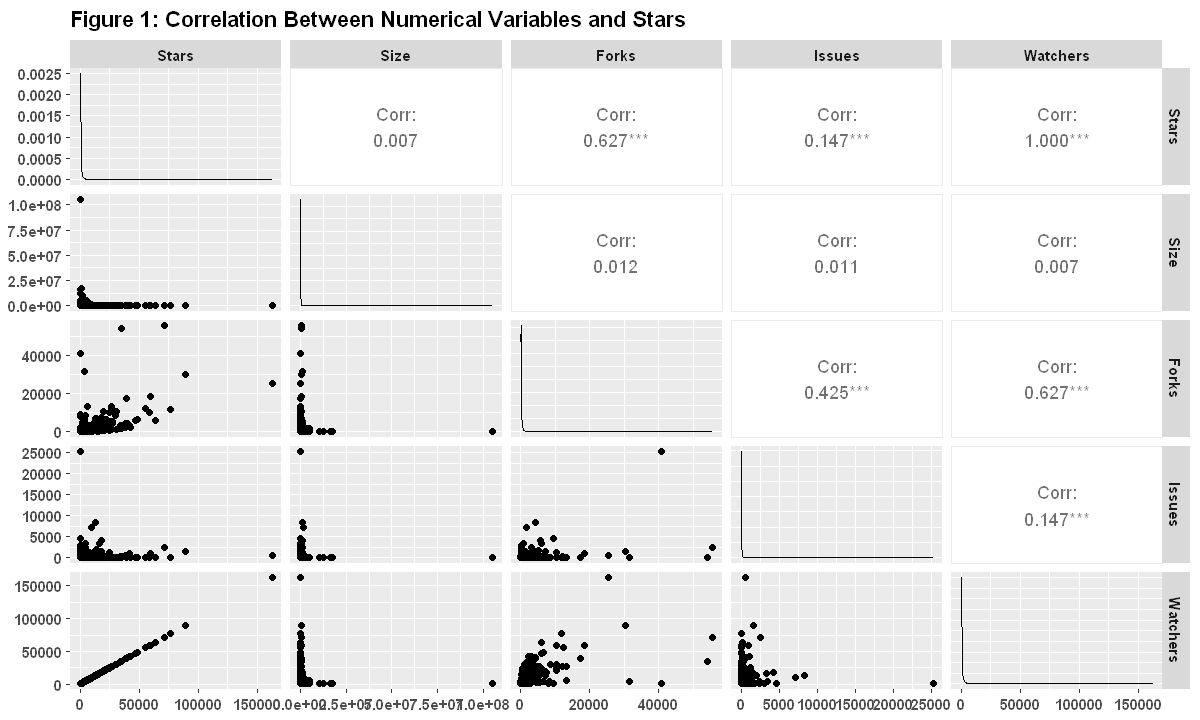

In [29]:
options(repr.plot.width = 10, repr.plot.height = 6)

# Pair plot: diagonal = distribution, upper = correlation, lower = scatter
# Key findings:
#   - Watchers ≈ Stars (perfect correlation) → must exclude from model
#   - Forks & Stars: strong positive correlation
#   - Issues & Size: weak correlation with Stars
git_pair_plots <- df_subset %>%
  select(Stars, Size, Forks, Issues, Watchers) %>%
  ggpairs(progress = FALSE) +
  theme(
    text       = element_text(face = "bold"),
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold")
  ) +
  labs(title = "Figure 1: Correlation Between Numerical Variables and Stars")

git_pair_plots

**Strong Correlations**: There is a strong positive correlation between Stars and Forks. This suggests that repositories with a higher number of stars also tend to have more forks. This relationship could imply that popular repositories are likely to be forked more often by users. Additionally, Watchers are perfectly correlated with Stars, as expected. Therefore, we might consider dropping Watchers when construcing the model to avoid multicollinearity.
**Weak or No Correlations**: Issues shows very little correlation with other numeric variables. This suggests that repository issues might not be a significant factor in determining popularity. Size has very low correlations with the other variables, suggesting that the physical size of a repository (in KB) is not strongly associated with its star count, forks, or issues.

#### **Visualization 2:**
This bar plot shows how boolean features relate to the average number of stars (Stars) received by GitHub repositories.

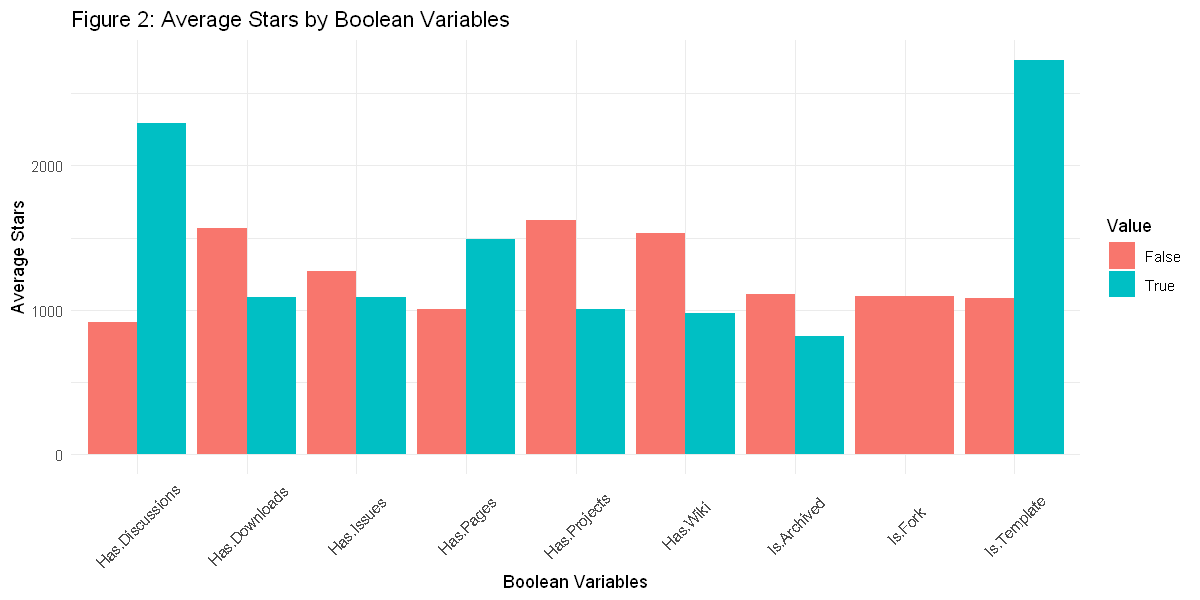

In [31]:
options(repr.plot.width = 10, repr.plot.height = 5)

# Compare average Stars between True/False groups for each boolean variable
boolean_features <- df_subset %>%
  select(Stars, `Has.Issues`:`Is.Template`) %>%
  gather(key = "Feature", value = "Boolean", -Stars) %>%
  group_by(Feature, Boolean) %>%
  summarize(avg_Stars = mean(Stars), .groups = 'drop')

boolean_barplot <- boolean_features %>%
  ggplot(aes(x = Feature, y = avg_Stars, fill = factor(Boolean))) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Figure 2: Average Stars by Boolean Variables",
    x     = "Boolean Variables",
    y     = "Average Stars",
    fill  = "Value"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 0.5))

boolean_barplot

This visualization allows us to easily identify by the density of points that most popular repositories do not have a discussion, have downloads on, do not have pages, have projects, and have a Wiki.

#### **Visualization 3:**
For the remaining categorical variables that are neither numerical or Boolean, we can create histograms according to the categories that exist. In order to visualize the languages categorical variable meaningfully, we tidied the data to filter for the most commonly appearing programming languages: Python, JavaScript, TypeScript, C++, and repositories not involving a coding language (`Language` = "NA") and converting the attribute as a factor-type. Amongst these languages, the variable can again be visualized with a histogram of the number of stars (x-axis) and the count of repositories (y-axis).

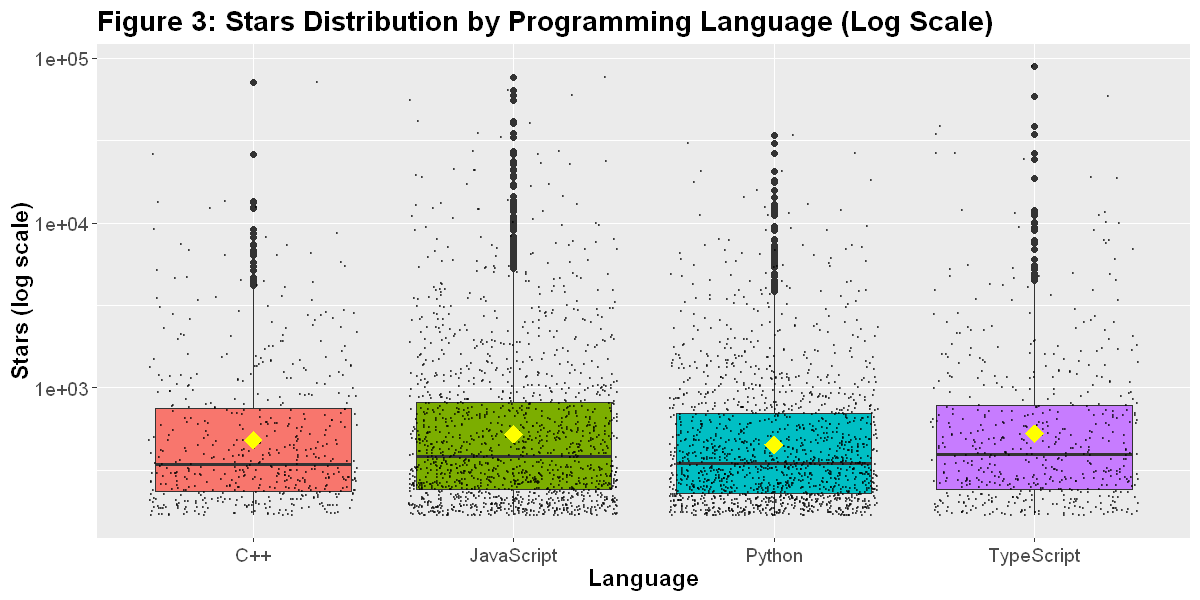

In [32]:
options(repr.plot.width = 10, repr.plot.height = 5)

# Filter top 4 languages only
top_languages <- c("Python", "JavaScript", "TypeScript", "C++")

language_data <- df_subset %>%
  filter(Language %in% top_languages)

# Box plot + jitter points + yellow diamond = mean
# Log scale applied because Stars distribution is heavily right-skewed
language_boxplot <- language_data %>%
  ggplot(aes(x = Language, y = Stars, fill = Language)) +
  geom_boxplot() +
  geom_jitter(color = "black", size = 0.2, alpha = 0.5) +
  stat_summary(fun = mean, colour = "yellow", geom = "point", shape = 18, size = 5) +
  scale_y_log10() +
  labs(
    title = "Figure 3: Stars Distribution by Programming Language (Log Scale)",
    x     = "Language",
    y     = "Stars (log scale)"
  ) +
  guides(fill = "none") +
  theme(
    text       = element_text(size = 14),
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold")
  )

language_boxplot

##### **Visualization 5:**
Histogram of Stars (shows the distribution of repository popularity)

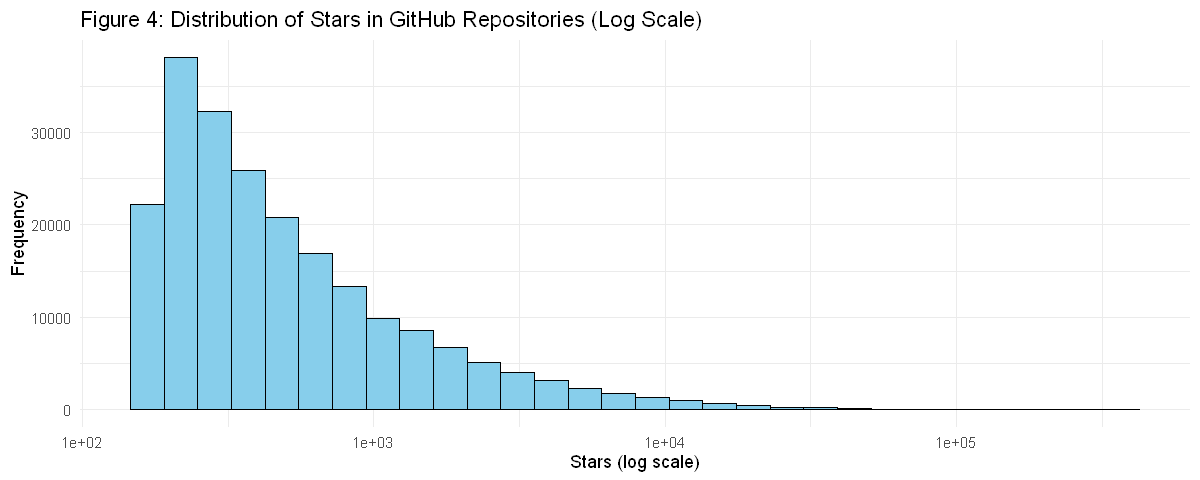

In [33]:
options(repr.plot.width = 10, repr.plot.height = 4)

# Stars distribution is heavily right-skewed
# Log scale makes the distribution readable
ggplot(df, aes(x = Stars)) +
  geom_histogram(bins = 30, color = "black", fill = "skyblue") +
  scale_x_log10() +
  labs(
    title = "Figure 4: Distribution of Stars in GitHub Repositories (Log Scale)",
    x     = "Stars (log scale)",
    y     = "Frequency"
  ) +
  theme_minimal()

**Observation:** The histogram reveals a highly skewed distribution, with a large number of repositories having relatively low star counts and only a few repositories achieving very high popularity. This concentration of repositories with lower star counts suggests that most GitHub projects are not widely starred, while a small subset has gained significant attention.

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information."
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


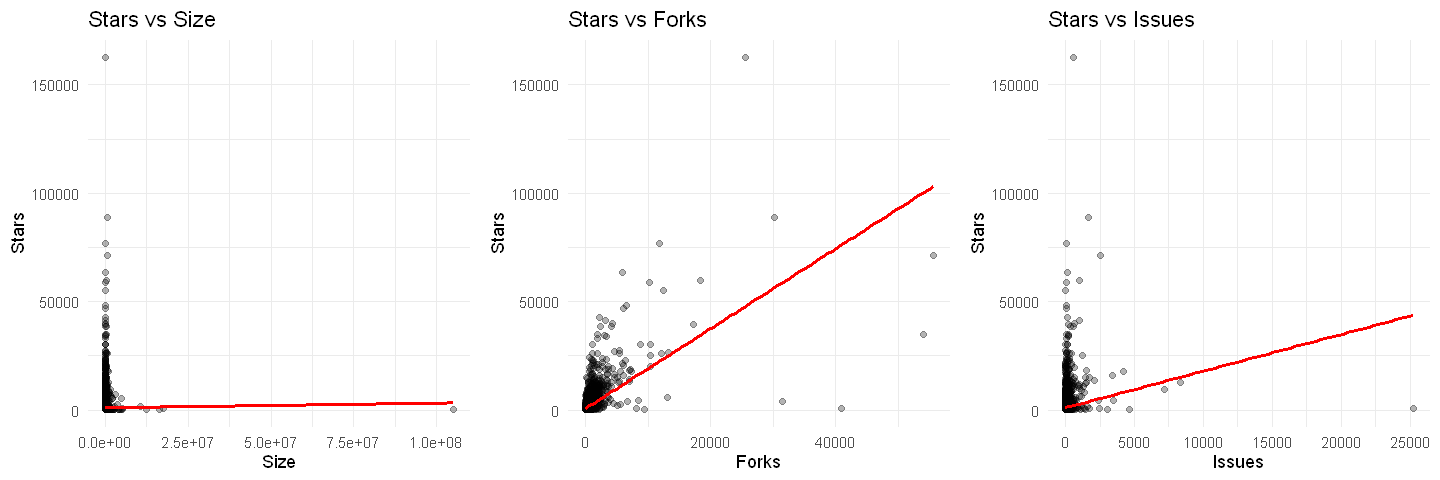

In [34]:
options(repr.plot.width = 12, repr.plot.height = 4)

# Simple linear fit between Stars and each numeric input variable
continuous_vars <- c("Size", "Forks", "Issues")

plots <- lapply(continuous_vars, function(var) {
  ggplot(df_cleaned, aes_string(x = var, y = "Stars")) +
    geom_point(alpha = 0.3) +
    geom_smooth(method = "lm", color = "red", se = FALSE) +
    labs(title = paste("Stars vs", var)) +
    theme_minimal()
})

# Arrange 3 plots side by side
do.call(grid.arrange, c(plots, ncol = 3))

In [35]:
# Fit full model and compute VIF to detect multicollinearity
# Rule of thumb: VIF > 5 = concern, VIF > 10 = serious problem
MLR_full <- lm(Stars ~ ., data = df_cleaned)
VIF_results <- vif(MLR_full)
round(VIF_results, 3)

# Expected: Watchers will have an extremely high VIF
# Reason: Watchers == Stars (perfect collinearity) → must be removed

Size             Forks            Issues          Watchers 
            1.000             2.029             1.258             1.712 
      Is.Archived        Has.Issues         Has.Pages     repo_age_days 
            1.038             1.021             1.015             1.098 
days_since_update 
            1.076

In [36]:
# Correlation matrix among numeric predictors
corr_matrix <- df_cleaned %>%
  select(Size, Forks, Issues, Watchers, repo_age_days, days_since_update) %>%
  cor() %>%
  round(3)

print(corr_matrix)

                    Size  Forks Issues Watchers repo_age_days days_since_update
Size               1.000  0.012  0.011    0.007        -0.009            -0.003
Forks              0.012  1.000  0.425    0.627         0.070            -0.047
Issues             0.011  0.425  1.000    0.147         0.027            -0.030
Watchers           0.007  0.627  0.147    1.000         0.069            -0.076
repo_age_days     -0.009  0.070  0.027    0.069         1.000             0.235
days_since_update -0.003 -0.047 -0.030   -0.076         0.235             1.000


In [37]:
set.seed(123)  # DO NOT CHANGE

# Add row id, then split 80% train / 20% test
GitHub_sample <- df_cleaned %>% mutate(id = row_number())

training_GitHub <- GitHub_sample %>%
  slice_sample(prop = 0.80, replace = FALSE)

testing_GitHub <- GitHub_sample %>%
  anti_join(training_GitHub, by = "id") %>%
  select(-id)

training_GitHub <- training_GitHub %>% select(-id)

cat('Training rows:', nrow(training_GitHub), '\n')
cat('Testing rows:', nrow(testing_GitHub), '\n')

Training rows: 8000 
Testing rows: 2000 


In [38]:
# Forward Selection: add variables one by one, keep the combination
# that minimizes BIC and Cp (lower = better fit with fewer variables)
GitHub_forward_sel <- regsubsets(
  Stars ~ .,
  data   = training_GitHub,
  method = "forward",
  nvmax  = ncol(training_GitHub) - 1
)

# Summarize evaluation metrics across models
GitHub_fwd_summary <- summary(GitHub_forward_sel)

fwd_metrics <- tibble(
  n_variables = 1:length(GitHub_fwd_summary$rss),
  RSS         = GitHub_fwd_summary$rss,
  BIC         = GitHub_fwd_summary$bic,
  Cp          = GitHub_fwd_summary$cp
)

print(fwd_metrics)

# Result: model with 4 variables (Size, Forks, Issues, Watchers) has best metrics
# However Watchers must be excluded due to perfect collinearity with Stars

# A tibble: 9 × 4
  n_variables      RSS      BIC      Cp
        <int>    <dbl>    <dbl>   <dbl>
1           1 1.26e-19 -551296. 4088.  
2           2 8.67e-20 -554274.  325.  
3           3 8.33e-20 -554584.    1.91
4           4 8.33e-20 -554576.    2.29
5           5 8.33e-20 -554569.    2.97
6           6 8.33e-20 -554560.    4.13
7           7 8.33e-20 -554552.    6.04
8           8 8.33e-20 -554543.    8.01
9           9 8.33e-20 -554534.   10   


In [40]:
# Model 1: includes Watchers — for reference only
# Watchers == Stars, so RMSE will be ~0 (not a valid model)
GitHub_full <- lm(Stars ~ Size + Forks + Issues + Watchers + `Is.Archived`,
                  data = training_GitHub)
summary(GitHub_full)


Call:
lm(formula = Stars ~ Size + Forks + Issues + Watchers + Is.Archived, 
    data = training_GitHub)

Residuals:
       Min         1Q     Median         3Q        Max 
-4.096e-10  2.000e-14  5.000e-14  7.000e-14  6.500e-12 

Coefficients:
                  Estimate Std. Error    t value Pr(>|t|)    
(Intercept)      1.278e-12  5.569e-14  2.296e+01   <2e-16 ***
Size            -8.058e-21  4.160e-20 -1.940e-01    0.846    
Forks            4.132e-15  6.363e-17  6.494e+01   <2e-16 ***
Issues          -3.542e-15  1.750e-16 -2.023e+01   <2e-16 ***
Watchers         1.000e+00  1.812e-17  5.518e+16   <2e-16 ***
Is.ArchivedTrue  4.296e-14  2.027e-13  2.120e-01    0.832    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.586e-12 on 7994 degrees of freedom
Multiple R-squared:      1,	Adjusted R-squared:      1 
F-statistic: 1.017e+33 on 5 and 7994 DF,  p-value: < 2.2e-16


In [42]:
# Model 2: best valid model from forward selection (Watchers excluded)
GitHub_No_Watchers <- lm(Stars ~ Forks + Issues + `Is.Archived`,
                         data = training_GitHub)
summary(GitHub_No_Watchers)


Call:
lm(formula = Stars ~ Forks + Issues + Is.Archived, data = training_GitHub)

Residuals:
   Min     1Q Median     3Q    Max 
-84190   -550   -438   -143 107037 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)      686.75144   33.45979  20.525   <2e-16 ***
Forks              2.19323    0.03066  71.542   <2e-16 ***
Issues            -1.87276    0.10595 -17.675   <2e-16 ***
Is.ArchivedTrue -255.72105  125.04394  -2.045   0.0409 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2830 on 7996 degrees of freedom
Multiple R-squared:  0.4013,	Adjusted R-squared:  0.4011 
F-statistic:  1786 on 3 and 7996 DF,  p-value: < 2.2e-16


In [46]:
# Model 3 & 4: simple linear regression baselines for comparison
GitHub_Simple_Forks  <- lm(Stars ~ Forks,  data = training_GitHub)
GitHub_Simple_Issues <- lm(Stars ~ Issues, data = training_GitHub)

cat('=== Simple Regression: Forks ===\n')
print(summary(GitHub_Simple_Forks))

cat('\n=== Simple Regression: Issues ===\n')
print(summary(GitHub_Simple_Issues))

=== Simple Regression: Forks ===

Call:
lm(formula = Stars ~ Forks, data = training_GitHub)

Residuals:
   Min     1Q Median     3Q    Max 
-79802   -530   -435   -166 112027 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 649.08692   32.93441   19.71   <2e-16 ***
Forks         1.95493    0.02806   69.66   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2885 on 7998 degrees of freedom
Multiple R-squared:  0.3776,	Adjusted R-squared:  0.3776 
F-statistic:  4853 on 1 and 7998 DF,  p-value: < 2.2e-16


=== Simple Regression: Issues ===

Call:
lm(formula = Stars ~ Issues, data = training_GitHub)

Residuals:
   Min     1Q Median     3Q    Max 
-37297   -838   -714   -320 160567 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1053.7320    40.8235   25.81   <2e-16 ***
Issues         1.4657     0.1218   12.03   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.

In [49]:
GitHub_RMSE_table <- bind_rows(
  tibble(
    Model = "Full Regression (Watchers included — invalid)",
    RMSE  = rmse(testing_GitHub$Stars, predict(GitHub_full, newdata = testing_GitHub))
  ),
  tibble(
    Model = "Forward Selection (No Watchers)",
    RMSE  = rmse(testing_GitHub$Stars, predict(GitHub_No_Watchers, newdata = testing_GitHub))
  ),
  tibble(
    Model = "Simple Regression (Forks only)",
    RMSE  = rmse(testing_GitHub$Stars, predict(GitHub_Simple_Forks, newdata = testing_GitHub))
  ),
  tibble(
    Model = "Simple Regression (Issues only)",
    RMSE  = rmse(testing_GitHub$Stars, predict(GitHub_Simple_Issues, newdata = testing_GitHub))
  )
)

print(GitHub_RMSE_table)

# A tibble: 4 × 2
  Model                                             RMSE
  <chr>                                            <dbl>
1 Full Regression (Watchers included — invalid) 3.97e-12
2 Forward Selection (No Watchers)               2.12e+ 3
3 Simple Regression (Forks only)                2.06e+ 3
4 Simple Regression (Issues only)               2.81e+ 3


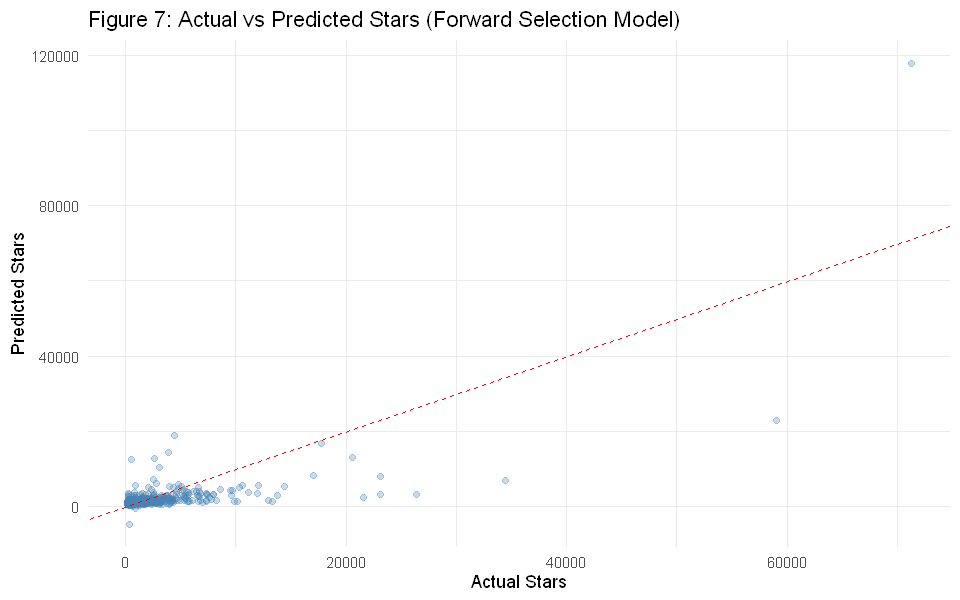

In [50]:
options(repr.plot.width = 8, repr.plot.height = 5)

# Generate predictions from the best model on test data
predicted <- predict(GitHub_No_Watchers, newdata = testing_GitHub)

# Scatter plot: points closer to the red dashed line = more accurate predictions
ggplot(data = NULL, aes(x = testing_GitHub$Stars, y = predicted)) +
  geom_point(alpha = 0.3, color = "steelblue") +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
  labs(
    title = "Figure 7: Actual vs Predicted Stars (Forward Selection Model)",
    x     = "Actual Stars",
    y     = "Predicted Stars"
  ) +
  theme_minimal()

In [51]:
# Add R-squared for the best model
summary(GitHub_No_Watchers)$r.squared

[1] 0.4012849